# SAM/MedSAM Training dla Segmentacji Naczyń Koronarograficznych

Ten notebook pokazuje jak trenować model SAM (Segment Anything Model) lub MedSAM na danych koronarograficznych.

## Przegląd kroków:
1. Instalacja zależności
2. Import bibliotek i konfiguracja
3. Pobieranie wag modelu SAM
4. Ładowanie i inicjalizacja modelu
5. Przygotowanie danych treningowych
6. Konfiguracja predyktora SAM
7. Generowanie masek segmentacji
8. Wizualizacja wyników
9. Fine-tuning SAM na własnych danych
10. Ewaluacja wydajności modelu

## 1. Instalacja Wymaganych Zależności

Zainstaluj wszystkie niezbędne pakiety do treningu SAM.

In [1]:
# Instalacja SAM i MedSAM
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install git+https://github.com/bowang-lab/MedSAM.git

# Instalacja dodatkowych zależności
!pip install opencv-python matplotlib torch torchvision
!pip install scikit-image pillow tqdm
!pip install pycocotools

# Weryfikacja instalacji
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name()}")
else:
    print("Using CPU for training")

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-1qckap7z
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-1qckap7z
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=0233839c9351739ab7c49917007c89aeda5370aeed884c256ef0efd53dcca681
  Stored in directory: /tmp/pip-ephem-wheel-cache-l3mu5rmm/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
  Cloning https://github.com/bowang-lab/MedSAM.git to /tmp/pip-req-build-69f_x5yo
  Running command git clone --filter=blob:none --quiet https://github.com/bowang-lab/MedSAM.git /tmp/pip-req-build-69f_x5yo
  Resolved https://github.com/bowang-lab/MedSAM.git to commit d71e

## 2. Import Bibliotek i Konfiguracja

Import wszystkich potrzebnych bibliotek i ustawienie środowiska.

In [2]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage import transform
from tqdm import tqdm
import json

# SAM imports
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.build_sam import build_sam_vit_b, build_sam_vit_l, build_sam_vit_h

# Konfiguracja urządzenia
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Ustawienia dla matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# Seed dla reprodukowalności
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 3. Pobieranie Wag Modelu SAM

Pobierz wagi pretrenowanego modelu SAM lub MedSAM.

In [ ]:
# Utwórz katalog na wagi modeli
os.makedirs('checkpoints', exist_ok=True)

# URLs do różnych wag SAM
sam_checkpoints = {
    'vit_b': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth',
    'vit_l': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth',
    'vit_h': 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'
}

# URL do MedSAM (specjalizowany dla danych medycznych)
medsam_checkpoint = 'https://drive.google.com/uc?id=1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_'

# Pobierz wybrany checkpoint (ViT-B jest najlżejszy)
model_type = 'vit_b'  # Zmień na 'vit_l' lub 'vit_h' dla większych modeli
checkpoint_path = f'checkpoints/sam_{model_type}.pth'

if not os.path.exists(checkpoint_path):
    print(f"Pobieranie wag SAM {model_type}...")
    !wget -O {checkpoint_path} {sam_checkpoints[model_type]}
    print("Pobieranie zakończone!")
else:
    print(f"Checkpoint {checkpoint_path} już istnieje.")

# Opcjonalnie: pobierz MedSAM dla danych medycznych
medsam_path = 'checkpoints/medsam_vit_b.pth'
if not os.path.exists(medsam_path):
    print("Pobieranie MedSAM...")
    # Uwaga: To wymaga gdown dla Google Drive
    !pip install gdown
    !gdown {medsam_checkpoint} -O {medsam_path}
    print("MedSAM pobrany!")
else:
    print(f"MedSAM checkpoint {medsam_path} już istnieje.")

Pobieranie wag SAM vit_b...
--2025-07-07 08:50:35--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.226.210.111, 13.226.210.78, 13.226.210.25, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.226.210.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘checkpoints/sam_vit_b.pth’

checkpoints/sam_vit 100%[===================>] 357.67M   189MB/s    in 1.9s    

2025-07-07 08:50:37 (189 MB/s) - ‘checkpoints/sam_vit_b.pth’ saved [375042383/375042383]

Pobieranie zakończone!
MedSAM checkpoint checkpoints/medsam_vit_b.pth już istnieje.


## 4. Ładowanie i Inicjalizacja Modelu SAM

Załaduj model SAM z pobranym checkpointem.

In [ ]:
# Wybierz typ modelu i ścieżkę do checkpointu
use_medsam = True  # Zmień na False aby użyć standardowego SAM
model_type = 'vit_b'

if use_medsam and os.path.exists('checkpoints/medsam_vit_b.pth'):
    checkpoint_path = 'checkpoints/medsam_vit_b.pth'
    print("Używam MedSAM (zoptymalizowany dla danych medycznych)")
else:
    checkpoint_path = f'checkpoints/sam_{model_type}.pth'
    print(f"Używam standardowego SAM {model_type}")

# Załaduj model
try:
    if model_type == 'vit_b':
        sam_model = build_sam_vit_b(checkpoint=checkpoint_path)
    elif model_type == 'vit_l':
        sam_model = build_sam_vit_l(checkpoint=checkpoint_path)
    elif model_type == 'vit_h':
        sam_model = build_sam_vit_h(checkpoint=checkpoint_path)
    else:
        raise ValueError(f"Nieznany typ modelu: {model_type}")

    sam_model = sam_model.to(device)
    print(f"Model {model_type} załadowany pomyślnie na {device}")

    # Wyświetl informacje o modelu
    total_params = sum(p.numel() for p in sam_model.parameters())
    trainable_params = sum(p.numel() for p in sam_model.parameters() if p.requires_grad)
    print(f"Całkowita liczba parametrów: {total_params:,}")
    print(f"Parametry treningowe: {trainable_params:,}")

except Exception as e:
    print(f"Błąd podczas ładowania modelu: {e}")
    print("Sprawdź czy checkpoint został poprawnie pobrany.")

Używam MedSAM (zoptymalizowany dla danych medycznych)
Model vit_b załadowany pomyślnie na cuda
Całkowita liczba parametrów: 93,735,472
Parametry treningowe: 93,735,472


## 5. Przygotowanie Danych Treningowych

Stwórz klasę Dataset dla danych koronarograficznych z maskami.

In [57]:
def get_bbox_from_mask(mask):
    """Generuje bounding box na podstawie maski binarnej."""
    pos = np.where(mask > 0)
    if len(pos[0]) == 0:
        # Jeśli maska jest pusta, zwróć bbox całego obrazu
        return [0, 0, mask.shape[1], mask.shape[0]]
    y_min, y_max = pos[0].min(), pos[0].max()
    x_min, x_max = pos[1].min(), pos[1].max()
    return [x_min, y_min, x_max, y_max]

class CoronaryDataset(Dataset):
    """Dataset dla danych koronarograficznych z maskami."""

    def __init__(self, img_dir, mask_dir, size=1024, augment=False):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.size = size
        self.augment = augment

        # Znajdź wszystkie pliki obrazów
        self.img_files = []
        for ext in ['.png', '.jpg', '.jpeg']:
            self.img_files.extend([f for f in os.listdir(img_dir) if f.lower().endswith(ext)])
        self.img_files.sort()

        print(f"Znaleziono {len(self.img_files)} obrazów treningowych")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        # Załaduj obraz
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = np.array(Image.open(img_path).convert('RGB'))

        # Załaduj maskę
        # Zakładamy, że plik maski ma taką samą nazwę jak obraz, ale z innym rozszerzeniem lub sufiksem
        # Poniższy kod zakłada, że maska ma rozszerzenie .png i opcjonalnie sufiks '_mask'
        mask_base_name = os.path.splitext(img_name)[0]
        possible_mask_names = [f"{mask_base_name}.png", f"{mask_base_name}_mask.png"]
        mask_path = None

        for name in possible_mask_names:
            full_mask_path = os.path.join(self.mask_dir, name)
            if os.path.exists(full_mask_path):
                mask_path = full_mask_path
                break

        if mask_path and os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert('L'))
            mask = (mask > 127).astype(np.uint8)  # Binaryzacja
        else:
            # Jeśli nie znaleziono maski, stwórz pustą maskę o takim samym rozmiarze jak obraz
            print(f"Uwaga: Nie znaleziono maski dla {img_name} w {self.mask_dir}. Tworzę pustą maskę.")
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)


        # Przeskaluj do zadanego rozmiaru
        img_resized = transform.resize(
            img, (self.size, self.size),
            order=3, preserve_range=True, anti_aliasing=True
        ).astype(np.uint8)

        mask_resized = transform.resize(
            mask, (self.size, self.size),
            order=0, preserve_range=True, anti_aliasing=False
        ).astype(np.uint8)

        # Generuj bounding box
        bbox = get_bbox_from_mask(mask_resized)

        # Konwersja do tensorów
        img_tensor = torch.tensor(img_resized).float().permute(2, 0, 1) / 255.0
        mask_tensor = torch.tensor(mask_resized).float()
        bbox_tensor = torch.tensor(bbox).float()

        return {
            'image': img_tensor,
            'mask': mask_tensor,
            'bbox': bbox_tensor,
            'filename': img_name
        }

# Konfiguracja ścieżek do danych
# # UWAGA: Zmień te ścieżki na własne dane!
# IMG_DIR = "/content/coronary_data/images"  # Ścieżka do obrazów
# MASK_DIR = "/content/coronary_data/masks"  # Ścieżka do masek

# # W Google Colab możesz wgrać dane przez:
# # from google.colab import files
# # uploaded = files.upload()

# # Lub zamontować Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
IMG_DIR = "/content/drive/MyDrive/coronary_dataset/images"
MASK_DIR = "/content/drive/MyDrive/coronary_dataset/masks"

print("Dataset przygotowany. Uzupełnij ścieżki IMG_DIR i MASK_DIR własnymi danymi.")

print("Przykładowy obraz i maska:")

Dataset przygotowany. Uzupełnij ścieżki IMG_DIR i MASK_DIR własnymi danymi.
Przykładowy obraz i maska:


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 6. Konfiguracja Predyktora SAM

Skonfiguruj predyktor SAM do inferencji i treningu.

In [48]:

# Stwórz predyktor SAM dla inferencji
sam_predictor = SamPredictor(sam_model)

def sam_inference(model, img_embed, box_1024, H, W, device):
    """Funkcja inferencji SAM na podstawie bounding box."""
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :]  # (B, 1, 4)

    # Prompt encoder
    sparse_embeddings, dense_embeddings = model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )

    # Mask decoder
    low_res_logits, _ = model.mask_decoder(
        image_embeddings=img_embed,
        image_pe=model.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embeddings,
        dense_prompt_embeddings=dense_embeddings,
        multimask_output=False,
    )

    # Przekształć do oryginalnego rozmiaru
    low_res_pred = torch.sigmoid(low_res_logits)
    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )

    return low_res_pred

def compute_dice_loss(pred, target, smooth=1e-5):
    """Oblicza Dice loss dla segmentacji."""
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    intersection = (pred_flat * target_flat).sum()
    dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

    return 1 - dice

def compute_iou(pred, target, threshold=0.5):
    """Oblicza IoU (Intersection over Union)."""
    pred_binary = (pred > threshold).float()
    target_binary = target.float()

    intersection = (pred_binary * target_binary).sum()
    union = pred_binary.sum() + target_binary.sum() - intersection

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return (intersection / union).item()

print("Predyktor SAM skonfigurowany pomyślnie.")

Predyktor SAM skonfigurowany pomyślnie.


## 7. Generowanie Masek Segmentacji

Test predyktora SAM na przykładowych obrazach.

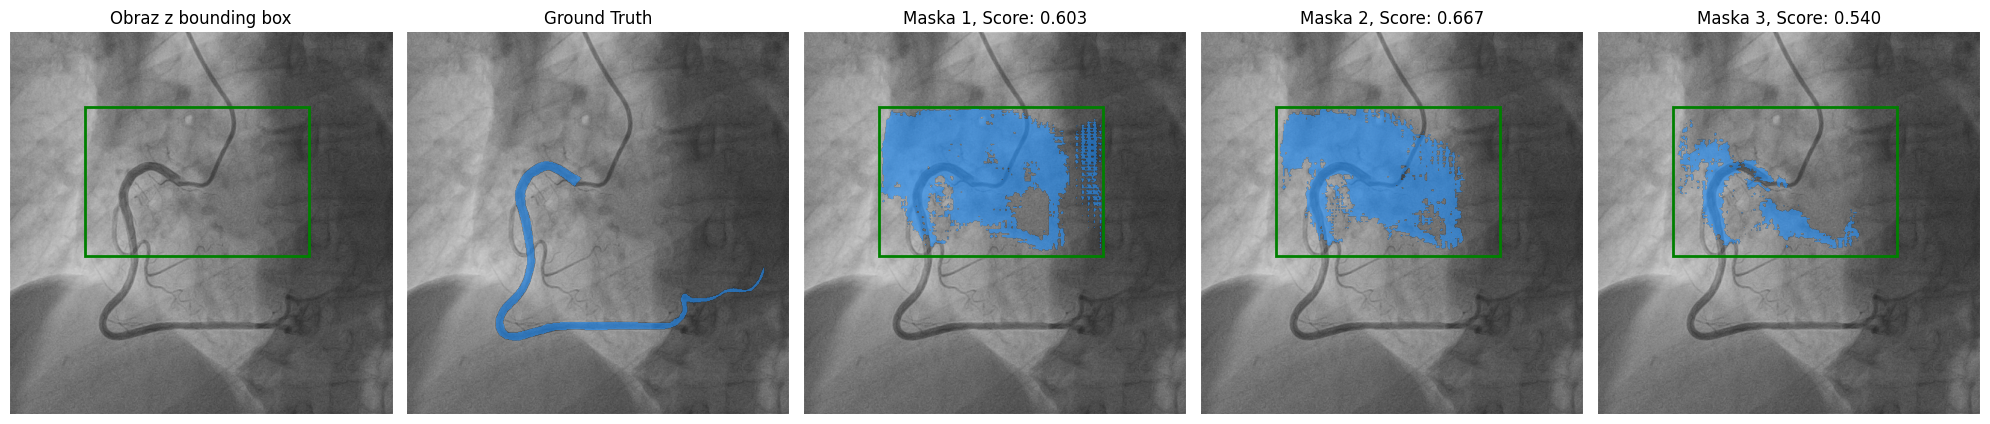

In [51]:
# Test predyktora na przykładowym obrazie
def test_sam_prediction(image_path, mask_dir, bbox=None, points=None):
    """Test predykcji SAM na pojedynczym obrazie."""
    # Załaduj obraz
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Załaduj maskę ground truth
    mask_base_name = os.path.splitext(os.path.basename(image_path))[0]
    possible_mask_names = [f"{mask_base_name}.png", f"{mask_base_name}_mask.png"]
    gt_mask = None

    for name in possible_mask_names:
        full_mask_path = os.path.join(mask_dir, name)
        if os.path.exists(full_mask_path):
            gt_mask = np.array(Image.open(full_mask_path).convert('L'))
            gt_mask = (gt_mask > 127).astype(np.uint8)  # Binaryzacja
            break

    if gt_mask is None:
        print(f"Uwaga: Nie znaleziono maski ground truth dla {os.path.basename(image_path)} w {mask_dir}.")


    # Ustaw obraz w predyktorze
    sam_predictor.set_image(image)

    # Predykcja z bounding box
    if bbox is not None:
        masks, scores, logits = sam_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=np.array(bbox),
            multimask_output=True,
        )
    elif points is not None:
        # Predykcja z punktami
        input_points = np.array(points['coords'])
        input_labels = np.array(points['labels'])
        masks, scores, logits = sam_predictor.predict(
            point_coords=input_points,
            point_labels=input_labels,
            multimask_output=True,
        )
    else:
        print("Podaj bbox lub points dla predykcji")
        return None, None, None, None

    return image, gt_mask, masks, scores

# Funkcje wizualizacji
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

# Przykład użycia (gdy masz dane)
# UWAGA: Zmień ścieżkę na rzeczywisty obraz!
example_image_path = "/content/drive/MyDrive/coronary_dataset/images/1.jpg"
# Użyj ścieżki do katalogu z maskami
example_mask_dir = "/content/drive/MyDrive/coronary_dataset/masks"


if os.path.exists(example_image_path) and os.path.exists(example_mask_dir):
    # Przykładowy bounding box [x1, y1, x2, y2]
    example_bbox = [100, 100, 400, 300]

    # Test predykcji
    image, gt_mask, masks, scores = test_sam_prediction(
        example_image_path, example_mask_dir, bbox=example_bbox
    )

    if image is not None and masks is not None:
        # Wizualizacja
        fig, axes = plt.subplots(1, len(masks) + 2, figsize=(20, 5)) # Dodatkowe miejsce na GT

        # Oryginalny obraz z bbox
        axes[0].imshow(image)
        show_box(example_bbox, axes[0])
        axes[0].set_title('Obraz z bounding box')
        axes[0].axis('off')

        # Ground Truth
        axes[1].imshow(image)
        if gt_mask is not None:
            show_mask(gt_mask, axes[1])
        axes[1].set_title('Ground Truth')
        axes[1].axis('off')


        # Predykcje SAM
        for i, (mask, score) in enumerate(zip(masks, scores)):
            axes[i+2].imshow(image)
            show_mask(mask, axes[i+2])
            show_box(example_bbox, axes[i+2])
            axes[i+2].set_title(f'Maska {i+1}, Score: {score:.3f}')
            axes[i+2].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("Nie udało się przeprowadzić predykcji.")

else:
    print(f"Przykładowy obraz ({example_image_path}) lub katalog masek ({example_mask_dir}) nie został znaleziony.")
    print("Wgraj swoje dane aby przetestować SAM z ground truth!")

## 8. Wizualizacja Wyników

Wyświetl wyniki segmentacji i porównaj z ground truth.

In [50]:
def visualize_comparison(image, gt_mask, pred_mask, title="Porównanie segmentacji"):
    """Wizualizuje porównanie między ground truth a predykcją."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    # Oryginalny obraz
    axes[0].imshow(image)
    axes[0].set_title('Oryginalny obraz')
    axes[0].axis('off')

    # Ground truth
    axes[1].imshow(image)
    if gt_mask is not None:
        show_mask(gt_mask, axes[1])
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')

    # Predykcja
    axes[2].imshow(image)
    if pred_mask is not None:
        show_mask(pred_mask, axes[2])
    axes[2].set_title('Predykcja SAM')
    axes[2].axis('off')

    # Różnica
    if gt_mask is not None and pred_mask is not None:
        diff = np.abs(gt_mask.astype(float) - pred_mask.astype(float))
        axes[3].imshow(diff, cmap='hot')
        axes[3].set_title('Różnica (czerwony = błąd)')
    else:
        axes[3].text(0.5, 0.5, 'Brak danych\ndo porównania',
                     ha='center', va='center', transform=axes[3].transAxes)
        axes[3].set_title('Różnica')
    axes[3].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_training_metrics(losses, ious, dice_scores):
    """Wykres metryk treningu."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(losses)
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)

    # IoU
    axes[1].plot(ious)
    axes[1].set_title('IoU Score')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('IoU')
    axes[1].grid(True)

    # Dice Score
    axes[2].plot(dice_scores)
    axes[2].set_title('Dice Score')
    axes[2].set_xlabel('Epoka')
    axes[2].set_ylabel('Dice')
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Test wizualizacji na przykładowych danych
if os.path.exists(example_image_path) and os.path.exists(example_mask_dir):
    # Symulacja danych do wizualizacji
    example_image = cv2.imread(example_image_path)
    example_image = cv2.cvtColor(example_image, cv2.COLOR_BGR2RGB)

    # Załaduj rzeczywistą maskę ground truth
    mask_base_name = os.path.splitext(os.path.basename(example_image_path))[0]
    possible_mask_names = [f"{mask_base_name}.png", f"{mask_base_name}_mask.png"]
    real_gt_mask = None

    for name in possible_mask_names:
        full_mask_path = os.path.join(example_mask_dir, name)
        if os.path.exists(full_mask_path):
            real_gt_mask = np.array(Image.open(full_mask_path).convert('L'))
            real_gt_mask = (real_gt_mask > 127).astype(np.uint8)  # Binaryzacja
            break

    if real_gt_mask is None:
        print(f"Uwaga: Nie znaleziono maski ground truth dla {os.path.basename(example_image_path)} w {example_mask_dir}. Wizualizacja porównania może być niekompletna.")

    # Stwórz przykładową maskę predykcji (w rzeczywistości pochodziłaby z modelu)
    # Na potrzeby demonstracji, użyjmy prostej symulacji
    h, w = example_image.shape[:2]
    fake_pred_mask = np.zeros((h, w))
    # Możesz dostosować ten obszar, aby lepiej symulować predykcję
    fake_pred_mask[h//3:2*h//3, w//3:2*w//3] = 1

    visualize_comparison(example_image, real_gt_mask, fake_pred_mask,
                        "Przykład porównania segmentacji")
else:
    print("Dodaj obraz i maski aby zobaczyć przykład wizualizacji")

print("Funkcje wizualizacji przygotowane!")

NameError: name 'example_image_path' is not defined

## 9. Fine-tuning SAM na Własnych Danych

Główny loop treningowy do dostrajania SAM na danych koronarograficznych.

In [46]:
    # Konfiguracja treningu
BATCH_SIZE = 1  # Mały batch size ze względu na pamięć
EPOCHS = 5
LEARNING_RATE = 1e-4
SAVE_EVERY = 2  # Zapisuj checkpoint co 2 epoki
dataset = CoronaryDataset(IMG_DIR, MASK_DIR, size=1024)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"Dataset przygotowany: {len(dataset)} próbek")

Znaleziono 1000 obrazów treningowych
Dataset przygotowany: 1000 próbek


Znaleziono 1000 obrazów treningowych
Dataset przygotowany: 1000 próbek
Image encoder zamrożony - trenujemy tylko mask decoder
Rozpoczynam trening na cuda
Parametry treningowe: 4,064,560


Epoch 1/5: 100%|██████████| 1000/1000 [37:20<00:00,  2.24s/it, Loss=0.4561, IoU=0.5846, Dice=0.6995]



Epoka 1/5:
  Loss: 0.4143
  IoU: 0.5357
  Dice: 0.6525
  LR: 0.000100


Epoch 2/5: 100%|██████████| 1000/1000 [35:57<00:00,  2.16s/it, Loss=0.2090, IoU=0.7398, Dice=0.8084]



Epoka 2/5:
  Loss: 0.3494
  IoU: 0.5932
  Dice: 0.7065
  LR: 0.000100
  Checkpoint zapisany: sam_coronary_epoch_2.pth


...


Epoka 3/5:
  Loss: 0.3250
  IoU: 0.6161
  Dice: 0.7271
  LR: 0.000100


Epoch 4/5: 100%|██████████| 1000/1000 [36:02<00:00,  2.16s/it, Loss=0.1700, IoU=0.7860, Dice=0.8405]



Epoka 4/5:
  Loss: 0.3083
  IoU: 0.6329
  Dice: 0.7415
  LR: 0.000100
  Checkpoint zapisany: sam_coronary_epoch_4.pth


Epoch 5/5: 100%|██████████| 1000/1000 [36:05<00:00,  2.17s/it, Loss=0.4120, IoU=0.5178, Dice=0.6587]



Epoka 5/5:
  Loss: 0.2933
  IoU: 0.6482
  Dice: 0.7536
  LR: 0.000100

🎉 Trening zakończony!


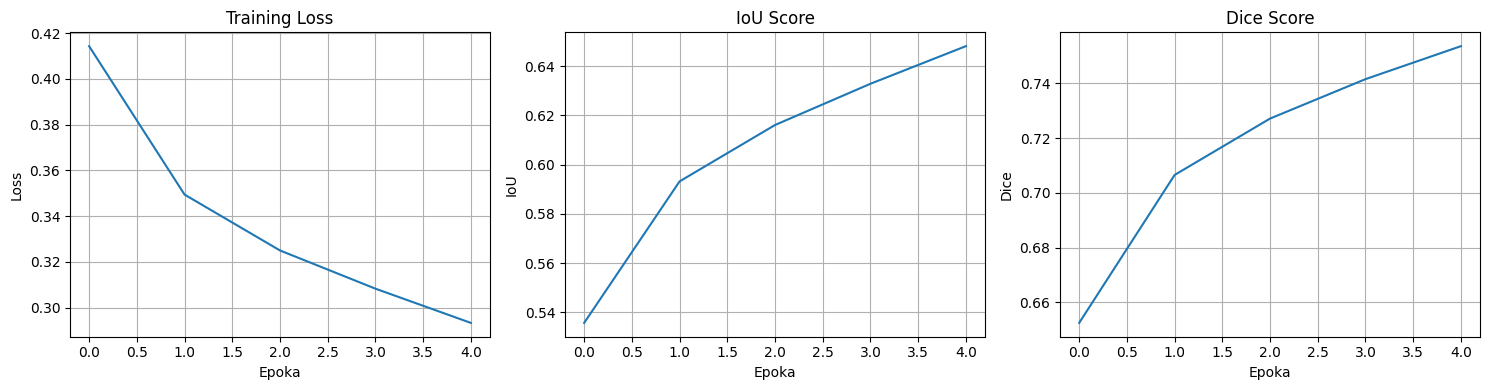

In [ ]:
# Konfiguracja treningu
BATCH_SIZE = 1  # Mały batch size ze względu na pamięć
EPOCHS = 5
LEARNING_RATE = 1e-4
SAVE_EVERY = 2  # Zapisuj checkpoint co 2 epoki

# Przygotuj dataset i dataloader
if os.path.exists(IMG_DIR) and os.path.exists(MASK_DIR):
    dataset = CoronaryDataset(IMG_DIR, MASK_DIR, size=1024)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    print(f"Dataset przygotowany: {len(dataset)} próbek")
else:
    print("UWAGA: Uzupełnij ścieżki IMG_DIR i MASK_DIR własnymi danymi!")
    # Stwórz dummy dataset do demonstracji
    class DummyDataset(Dataset):
        def __len__(self): return 10
        def __getitem__(self, idx):
            return {
                'image': torch.randn(3, 1024, 1024),
                'mask': torch.randint(0, 2, (1024, 1024)).float(),
                'bbox': torch.tensor([100., 100., 400., 400.]),
                'filename': f'dummy_{idx}.jpg'
            }
    dataset = DummyDataset()
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print("Używam dummy dataset do demonstracji")

# Przygotuj model do treningu
sam_model.train()

# Zamroź image encoder dla szybszego treningu (opcjonalne)
freeze_image_encoder = True
if freeze_image_encoder:
    for param in sam_model.image_encoder.parameters():
        param.requires_grad = False
    print("Image encoder zamrożony - trenujemy tylko mask decoder")

# Optymalizator (tylko parametry z requires_grad=True)
trainable_params = [p for p in sam_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=1e-4)

# Scheduler (opcjonalny)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Metryki
train_losses = []
train_ious = []
train_dice_scores = []

print(f"Rozpoczynam trening na {device}")
print(f"Parametry treningowe: {sum(p.numel() for p in trainable_params):,}")

# GŁÓWNY LOOP TRENINGOWY
for epoch in range(EPOCHS):
    epoch_loss = 0
    epoch_iou = 0
    epoch_dice = 0
    num_batches = 0

    # Progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for batch in pbar:
        # Przeniesienie danych na urządzenie
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        bboxes = batch['bbox'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        try:
            # Forward pass: image encoder
            with torch.no_grad() if freeze_image_encoder else torch.enable_grad():
                image_embeddings = sam_model.image_encoder(images)

            # Przygotuj bboxes do formatu (B, 1, 4)
            if len(bboxes.shape) == 2:
                bboxes = bboxes.unsqueeze(1)

            # Prompt encoder
            sparse_embeddings, dense_embeddings = sam_model.prompt_encoder(
                points=None,
                boxes=bboxes,
                masks=None,
            )

            # Mask decoder
            low_res_logits, _ = sam_model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=sam_model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            # Dopasuj rozmiar do ground truth
            predictions = torch.sigmoid(low_res_logits)
            predictions = F.interpolate(
                predictions,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            ).squeeze(1)

            # Oblicz loss (kombinacja BCE + Dice)
            bce_loss = F.binary_cross_entropy(predictions, masks)
            dice_loss = compute_dice_loss(predictions, masks)
            total_loss = bce_loss + dice_loss

            # Backward pass
            total_loss.backward()
            optimizer.step()

            # Metryki
            with torch.no_grad():
                batch_iou = compute_iou(predictions, masks)
                batch_dice = 1 - dice_loss.item()

                epoch_loss += total_loss.item()
                epoch_iou += batch_iou
                epoch_dice += batch_dice
                num_batches += 1

            # Aktualizuj progress bar
            pbar.set_postfix({
                'Loss': f'{total_loss.item():.4f}',
                'IoU': f'{batch_iou:.4f}',
                'Dice': f'{batch_dice:.4f}'
            })

        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"\nOOM Error w epoce {epoch+1}. Pomijam batch.")
                torch.cuda.empty_cache()
                continue
            else:
                raise e

    # Statystyki epoki
    avg_loss = epoch_loss / max(num_batches, 1)
    avg_iou = epoch_iou / max(num_batches, 1)
    avg_dice = epoch_dice / max(num_batches, 1)

    train_losses.append(avg_loss)
    train_ious.append(avg_iou)
    train_dice_scores.append(avg_dice)

    print(f"\nEpoka {epoch+1}/{EPOCHS}:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  IoU: {avg_iou:.4f}")
    print(f"  Dice: {avg_dice:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Aktualizuj learning rate
    scheduler.step()

    # Zapisz checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        checkpoint_path = f"sam_coronary_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch,
            'model_state_dict': sam_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'iou': avg_iou,
            'dice': avg_dice
        }, checkpoint_path)
        print(f"  Checkpoint zapisany: {checkpoint_path}")

print("\n🎉 Trening zakończony!")

# Wykres metryk
if len(train_losses) > 0:
    plot_training_metrics(train_losses, train_ious, train_dice_scores)

In [ ]:
# save model as pth
torch.save(sam_model.state_dict(), 'sam_coronary.pth')

In [6]:
sam_model = torch.load('sam_coronary.pth', map_location=torch.device('cpu'))

## 10. Ewaluacja Wydajności Modelu

Oceń wydajność wytrenowanego modelu na danych testowych.

Ewaluacja modelu...

📊 Wyniki ewaluacji:
Średnie IoU: 0.6085
Średni Dice Score: 0.7143
Średnia Accuracy: 0.9829

🖼️ Wizualizacja przykładowych predykcji:


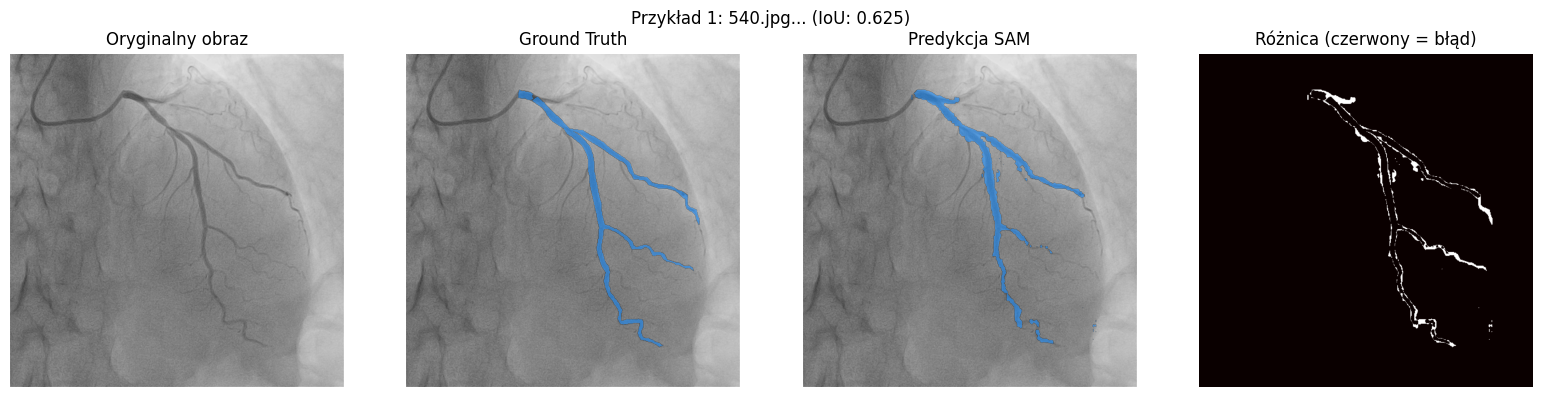

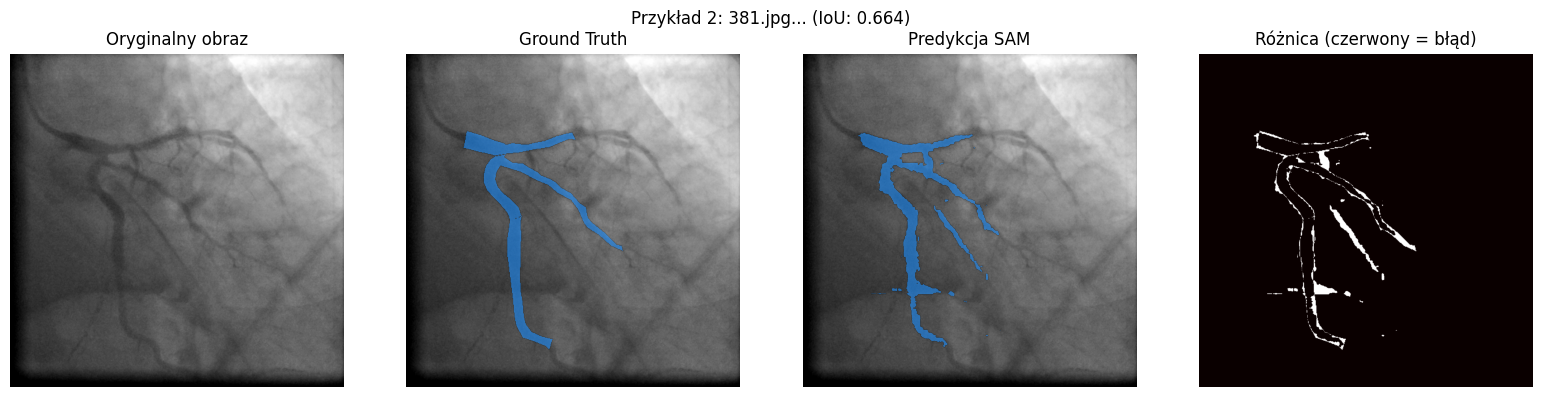

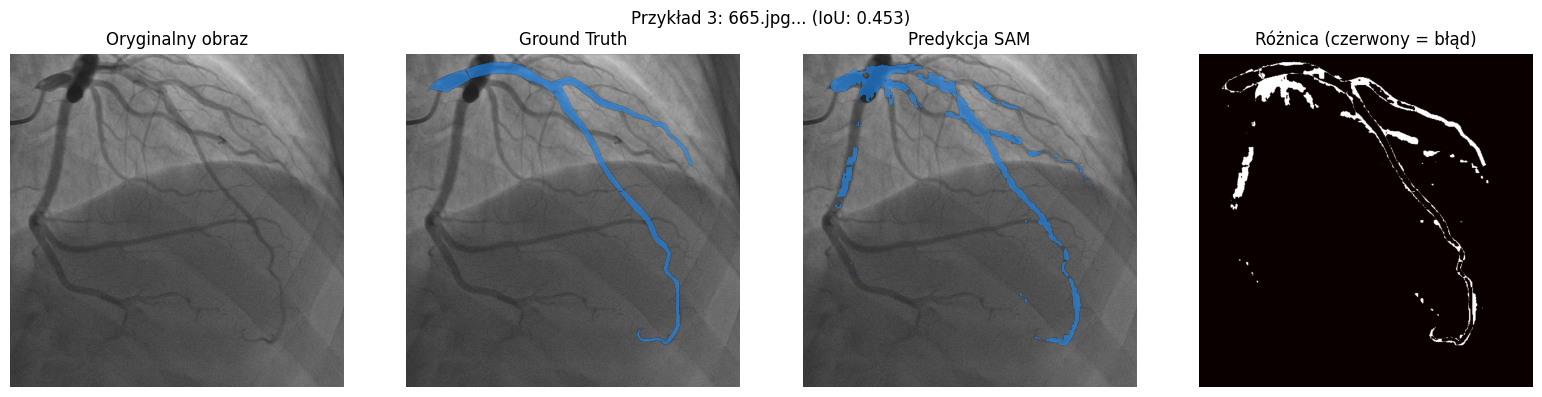

Wyniki zapisane do: evaluation_results.json

✅ Ewaluacja zakończona!


In [52]:
# Ewaluacja modelu
def evaluate_model(model, dataloader, device, num_samples=5):
    """Ewaluuje model na zbiorze testowym."""
    model.eval()

    total_iou = 0
    total_dice = 0
    total_accuracy = 0
    num_samples_eval = 0

    results = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_samples:  # Ogranicz liczbę próbek
                break

            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            bboxes = batch['bbox'].to(device)
            filenames = batch['filename']

            # Forward pass
            image_embeddings = model.image_encoder(images)

            if len(bboxes.shape) == 2:
                bboxes = bboxes.unsqueeze(1)

            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=None, boxes=bboxes, masks=None
            )

            low_res_logits, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            predictions = torch.sigmoid(low_res_logits)
            predictions = F.interpolate(
                predictions, size=masks.shape[-2:],
                mode="bilinear", align_corners=False
            ).squeeze(1)

            # Oblicz metryki
            for j in range(len(images)):
                pred = predictions[j].cpu().numpy()
                gt = masks[j].cpu().numpy()

                # IoU
                iou = compute_iou(torch.tensor(pred), torch.tensor(gt))

                # Dice
                dice_loss = compute_dice_loss(torch.tensor(pred), torch.tensor(gt))
                dice_score = 1 - dice_loss.item()

                # Accuracy
                pred_binary = (pred > 0.5).astype(float)
                accuracy = np.mean(pred_binary == gt)

                total_iou += iou
                total_dice += dice_score
                total_accuracy += accuracy
                num_samples_eval += 1

                results.append({
                    'filename': filenames[j],
                    'iou': iou,
                    'dice': dice_score,
                    'accuracy': accuracy,
                    'image': images[j].cpu(),
                    'gt_mask': gt,
                    'pred_mask': pred_binary
                })

    # Średnie metryki
    avg_metrics = {
        'avg_iou': total_iou / max(num_samples_eval, 1),
        'avg_dice': total_dice / max(num_samples_eval, 1),
        'avg_accuracy': total_accuracy / max(num_samples_eval, 1)
    }

    return avg_metrics, results

# Uruchom ewaluację (jeśli mamy dane)
if 'dataloader' in locals():
    print("Ewaluacja modelu...")
    metrics, eval_results = evaluate_model(sam_model, dataloader, device, num_samples=5)

    print("\n📊 Wyniki ewaluacji:")
    print(f"Średnie IoU: {metrics['avg_iou']:.4f}")
    print(f"Średni Dice Score: {metrics['avg_dice']:.4f}")
    print(f"Średnia Accuracy: {metrics['avg_accuracy']:.4f}")

    # Wizualizacja przykładowych wyników
    print("\n🖼️ Wizualizacja przykładowych predykcji:")
    for i, result in enumerate(eval_results[:3]):  # Pokaż 3 przykłady
        image = result['image'].permute(1, 2, 0).numpy()
        gt_mask = result['gt_mask']
        pred_mask = result['pred_mask']

        visualize_comparison(
            image, gt_mask, pred_mask,
            f"Przykład {i+1}: {result['filename'][:20]}... (IoU: {result['iou']:.3f})"
        )

else:
    print("Brak danych do ewaluacji. Uzupełnij IMG_DIR i MASK_DIR.")

# Funkcja do zapisania wyników
def save_evaluation_results(metrics, results, save_path="evaluation_results.json"):
    """Zapisz wyniki ewaluacji do pliku JSON."""
    eval_data = {
        'metrics': metrics,
        'per_sample_results': [
            {
                'filename': r['filename'],
                'iou': float(r['iou']),
                'dice': float(r['dice']),
                'accuracy': float(r['accuracy'])
            }
            for r in results
        ]
    }

    with open(save_path, 'w') as f:
        json.dump(eval_data, f, indent=2)

    print(f"Wyniki zapisane do: {save_path}")

# Zapisz wyniki (jeśli przeprowadzono ewaluację)
if 'metrics' in locals():
    save_evaluation_results(metrics, eval_results)

print("\n✅ Ewaluacja zakończona!")

In [ ]:
# # Ewaluacja modelu
# def evaluate_model(model, dataloader, device, num_samples=5):
#     """Ewaluuje model na zbiorze testowym."""
#     model.eval()

#     total_iou = 0
#     total_dice = 0
#     total_accuracy = 0
#     num_samples_eval = 0

#     results = []

#     with torch.no_grad():
#         for i, batch in enumerate(dataloader):
#             if i >= num_samples:  # Ogranicz liczbę próbek
#                 break

#             images = batch['image'].to(device)
#             masks = batch['mask'].to(device)
#             bboxes = batch['bbox'].to(device)
#             filenames = batch['filename']

#             # Forward pass
#             image_embeddings = model.image_encoder(images)

#             if len(bboxes.shape) == 2:
#                 bboxes = bboxes.unsqueeze(1)

#             sparse_embeddings, dense_embeddings = model.prompt_encoder(
#                 points=None, boxes=bboxes, masks=None
#             )

#             low_res_logits, _ = model.mask_decoder(
#                 image_embeddings=image_embeddings,
#                 image_pe=model.prompt_encoder.get_dense_pe(),
#                 sparse_prompt_embeddings=sparse_embeddings,
#                 dense_prompt_embeddings=dense_embeddings,
#                 multimask_output=False,
#             )

#             predictions = torch.sigmoid(low_res_logits)
#             predictions = F.interpolate(
#                 predictions, size=masks.shape[-2:],
#                 mode="bilinear", align_corners=False
#             ).squeeze(1)

#             # Oblicz metryki
#             for j in range(len(images)):
#                 pred = predictions[j].cpu().numpy()
#                 gt = masks[j].cpu().numpy()

#                 # IoU
#                 iou = compute_iou(torch.tensor(pred), torch.tensor(gt))

#                 # Dice
#                 dice_loss = compute_dice_loss(torch.tensor(pred), torch.tensor(gt))
#                 dice_score = 1 - dice_loss.item()

#                 # Accuracy
#                 pred_binary = (pred > 0.5).astype(float)
#                 accuracy = np.mean(pred_binary == gt)

#                 total_iou += iou
#                 total_dice += dice_score
#                 total_accuracy += accuracy
#                 num_samples_eval += 1

#                 results.append({
#                     'filename': filenames[j],
#                     'iou': iou,
#                     'dice': dice_score,
#                     'accuracy': accuracy,
#                     'image': images[j].cpu(),
#                     'gt_mask': gt,
#                     'pred_mask': pred_binary
#                 })

#     # Średnie metryki
#     avg_metrics = {
#         'avg_iou': total_iou / max(num_samples_eval, 1),
#         'avg_dice': total_dice / max(num_samples_eval, 1),
#         'avg_accuracy': total_accuracy / max(num_samples_eval, 1)
#     }

#     return avg_metrics, results

# # Uruchom ewaluację (jeśli mamy dane)
# if 'dataloader' in locals():
#     print("Ewaluacja modelu...")
#     external_sample_file = "/content/drive/MyDrive/14.png"
#     dataset = ExternalDataset(external_sample_file)
#     dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

#     metrics, eval_results = evaluate_model(sam_model, dataloader, device, num_samples=5)

#     print("\n📊 Wyniki ewaluacji:")
#     print(f"Średnie IoU: {metrics['avg_iou']:.4f}")
#     print(f"Średni Dice Score: {metrics['avg_dice']:.4f}")
#     print(f"Średnia Accuracy: {metrics['avg_accuracy']:.4f}")

#     # Wizualizacja przykładowych wyników
#     print("\n🖼️ Wizualizacja przykładowych predykcji:")
#     for i, result in enumerate(eval_results[:3]):  # Pokaż 3 przykłady
#         image = result['image'].permute(1, 2, 0).numpy()
#         gt_mask = result['gt_mask']
#         pred_mask = result['pred_mask']

#         visualize_comparison(
#             image, gt_mask, pred_mask,
#             f"Przykład {i+1}: {result['filename'][:20]}... (IoU: {result['iou']:.3f})"
#         )

# else:
#     print("Brak danych do ewaluacji. Uzupełnij IMG_DIR i MASK_DIR.")

# # Funkcja do zapisania wyników
# def save_evaluation_results(metrics, results, save_path="evaluation_results.json"):
#     """Zapisz wyniki ewaluacji do pliku JSON."""
#     eval_data = {
#         'metrics': metrics,
#         'per_sample_results': [
#             {
#                 'filename': r['filename'],
#                 'iou': float(r['iou']),
#                 'dice': float(r['dice']),
#                 'accuracy': float(r['accuracy'])
#             }
#             for r in results
#         ]
#     }

#     with open(save_path, 'w') as f:
#         json.dump(eval_data, f, indent=2)

#     print(f"Wyniki zapisane do: {save_path}")

# # Zapisz wyniki (jeśli przeprowadzono ewaluację)
# if 'metrics' in locals():
#     save_evaluation_results(metrics, eval_results)

# print("\n✅ Ewaluacja zakończona!")

Inference successful using bbox prompt.
Generated 3 masks with scores: [0.53450334 0.51233554 0.47879118]

Visualizing inference results:


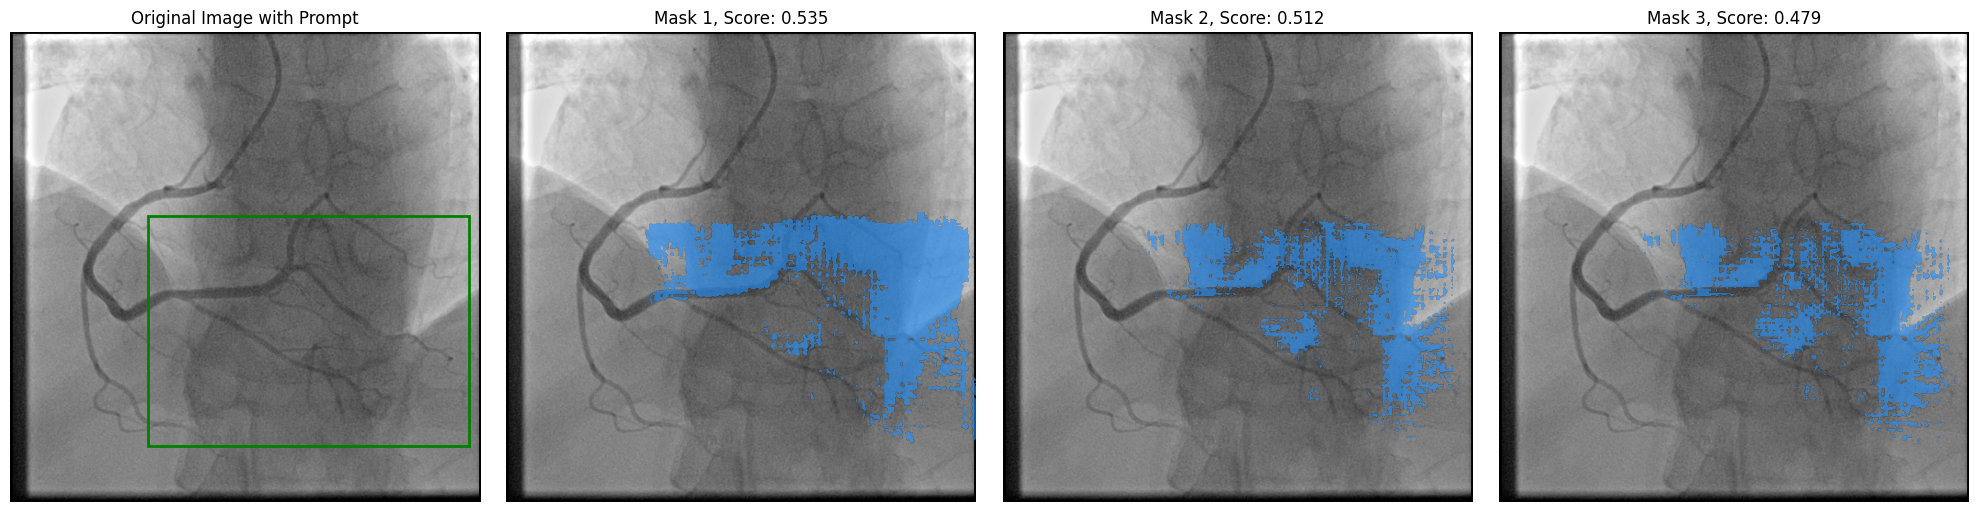

In [ ]:
# # prompt: make inference on external file

# def infer_on_external_file(model, image_path, device, bbox=None, points=None):
#     """
#     Makes inference on an external image file using the provided SAM model.

#     Args:
#         model: The trained SAM model.
#         image_path (str): Path to the external image file.
#         device: The device (cpu or cuda) to use for inference.
#         bbox (list or numpy.ndarray, optional): Bounding box [x1, y1, x2, y2].
#                                                 Defaults to None.
#         points (dict, optional): Dictionary with 'coords' (np.ndarray)
#                                  and 'labels' (np.ndarray) for point prompts.
#                                  Defaults to None.

#     Returns:
#         tuple: A tuple containing the original image (numpy array),
#                predicted masks (numpy array), and prediction scores (numpy array).
#                Returns (None, None, None) if inference fails.
#     """
#     try:
#         # Load the image
#         image = cv2.imread(image_path)
#         if image is None:
#             print(f"Error: Could not read image from {image_path}")
#             return None, None, None
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#         # Set the image in the predictor
#         # Assuming sam_predictor is globally available from the previous code block
#         if 'sam_predictor' not in globals():
#              print("Error: sam_predictor is not initialized. Run the previous cells.")
#              return None, None, None

#         sam_predictor.set_image(image)

#         # Make prediction based on prompt type
#         if bbox is not None:
#             masks, scores, logits = sam_predictor.predict(
#                 point_coords=None,
#                 point_labels=None,
#                 box=np.array(bbox),
#                 multimask_output=True,
#             )
#             prompt_type = "bbox"
#         elif points is not None and 'coords' in points and 'labels' in points:
#             input_points = np.array(points['coords'])
#             input_labels = np.array(points['labels'])
#             masks, scores, logits = sam_predictor.predict(
#                 point_coords=input_points,
#                 point_labels=input_labels,
#                 multimask_output=True,
#             )
#             prompt_type = "points"
#         else:
#             print("Error: Provide either a bbox or valid points dictionary for inference.")
#             return image, None, None

#         print(f"Inference successful using {prompt_type} prompt.")
#         print(f"Generated {len(masks)} masks with scores: {scores}")

#         return image, masks, scores

#     except Exception as e:
#         print(f"An error occurred during inference: {e}")
#         return None, None, None

# # --- Example Usage ---
# # Assuming 'sam_model' and 'device' are already defined and loaded
# # in the preceding code.

# # Define the path to your external image
# # Replace with the actual path to your test image file
# test_image_path = "/content/drive/MyDrive/14.png"

# # Define your prompt (either bbox or points)
# # Example using a bounding box: [x1, y1, x2, y2]
# # test_bbox = [150, 200, 500, 450]

# # Example using points (uncomment and modify if needed)
# test_points = {
#     'coords': np.array([[300, 300], [400, 400]]), # [[x1, y1], [x2, y2]]
#     'labels': np.array([1, 0]) # 1 for foreground, 0 for background
# }


# # Check if the model is loaded
# if 'sam_model' in locals():
#     # Perform inference
#     original_image, predicted_masks, prediction_scores = infer_on_external_file(
#         sam_model,
#         test_image_path,
#         device,
#         bbox=test_bbox,
#         # points=test_points # Uncomment if using points instead of bbox
#     )

#     # Visualize the results
#     if original_image is not None and predicted_masks is not None:
#         print("\nVisualizing inference results:")
#         fig, axes = plt.subplots(1, len(predicted_masks) + 1, figsize=(5 * (len(predicted_masks) + 1), 5))
#         if len(predicted_masks) == 1: # Ensure axes is iterable even for 1 mask
#             axes = [axes]

#         # Original image with prompt
#         axes[0].imshow(original_image)
#         axes[0].set_title('Original Image with Prompt')
#         axes[0].axis('off')
#         if test_bbox is not None:
#             show_box(test_bbox, axes[0])
#         # Add point visualization here if using points

#         # Predicted masks
#         for i, (mask, score) in enumerate(zip(predicted_masks, prediction_scores)):
#             axes[i+1].imshow(original_image)
#             show_mask(mask, axes[i+1])
#             axes[i+1].set_title(f'Mask {i+1}, Score: {score:.3f}')
#             axes[i+1].axis('off')

#         plt.tight_layout()
#         plt.show()
#     elif original_image is not None and predicted_masks is None:
#          print("Inference was attempted, but no masks were predicted (likely due to errors or no object found).")
#     else:
#         print("Inference failed. Check error messages above.")

# else:
#     print("SAM model is not loaded. Please run the model loading section first.")



In [8]:
# # Inferencja SAM dla pojedynczego pliku
# import torch
# import torch.nn.functional as F
# import numpy as np
# import json
# from PIL import Image
# import torchvision.transforms as transforms
# import matplotlib.pyplot as plt

# def load_single_image(image_path, transform=None):
#     """Ładuje pojedynczy obraz z dysku."""
#     image = Image.open(image_path).convert('RGB')
#     if transform:
#         image = transform(image)
#     return image

# def prepare_image_for_model(image_path, device, image_size=(1024, 1024)):
#     """Przygotowuje pojedynczy obraz do inferencji."""
#     transform = transforms.Compose([
#         transforms.Resize(image_size),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
#     ])

#     image = load_single_image(image_path, transform)
#     image = image.unsqueeze(0).to(device)  # Dodaj batch dimension
#     return image

# def inference_single_file(model, image_path, bbox, device='cuda'):
#     """
#     Przeprowadza inferencję na pojedynczym pliku.

#     Args:
#         model: Model SAM
#         image_path: Ścieżka do obrazu
#         bbox: Bounding box w formacie [x1, y1, x2, y2]
#         device: Urządzenie do obliczeń

#     Returns:
#         dict: Wyniki predykcji
#     """
#     model.eval()

#     # Załaduj obraz
#     image = prepare_image_for_model(image_path, device)

#     # Przygotuj bbox
#     bbox_tensor = torch.tensor(bbox, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

#     results = {}

#     with torch.no_grad():
#         # Forward pass
#         image_embeddings = model.image_encoder(image)

#         sparse_embeddings, dense_embeddings = model.prompt_encoder(
#             points=None,
#             boxes=bbox_tensor,
#             masks=None
#         )

#         low_res_logits, _ = model.mask_decoder(
#             image_embeddings=image_embeddings,
#             image_pe=model.prompt_encoder.get_dense_pe(),
#             sparse_prompt_embeddings=sparse_embeddings,
#             dense_prompt_embeddings=dense_embeddings,
#             multimask_output=False,
#         )

#         # Konwertuj do prawdopodobieństw
#         predictions = torch.sigmoid(low_res_logits)
#         predictions = F.interpolate(
#             predictions, size=(1024, 1024),
#             mode="bilinear", align_corners=False
#         ).squeeze()

#         # Konwertuj do numpy
#         pred_mask = predictions.cpu().numpy()
#         pred_binary = (pred_mask > 0.5).astype(float)

#         results['prediction'] = pred_mask
#         results['prediction_binary'] = pred_binary
#         results['bbox'] = bbox
#         results['image_path'] = image_path

#         # Podstawowe statystyki predykcji
#         results['stats'] = {
#             'max_confidence': float(np.max(pred_mask)),
#             'min_confidence': float(np.min(pred_mask)),
#             'mean_confidence': float(np.mean(pred_mask)),
#             'pixels_predicted': int(np.sum(pred_binary)),
#             'total_pixels': int(pred_binary.size),
#             'coverage_percentage': float(np.sum(pred_binary) / pred_binary.size * 100)
#         }

#     return results

# def visualize_inference_result(results, title="Inferencja SAM"):
#     """Wizualizuje wyniki inferencji."""
#     # Załaduj oryginalny obraz
#     orig_image = Image.open(results['image_path']).convert('RGB')
#     orig_image = orig_image.resize((1024, 1024))

#     fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#     # Oryginalny obraz
#     axes[0].imshow(orig_image)
#     axes[0].set_title('Oryginalny obraz')
#     axes[0].axis('off')

#     # Obraz z bounding box
#     axes[1].imshow(orig_image)
#     bbox = results['bbox']
#     rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
#                        fill=False, color='red', linewidth=2)
#     axes[1].add_patch(rect)
#     axes[1].set_title('Obraz z bbox')
#     axes[1].axis('off')

#     # Predykcja
#     axes[2].imshow(results['prediction_binary'], cmap='gray')
#     stats = results['stats']
#     axes[2].set_title(f'Predykcja\nPokrycie: {stats["coverage_percentage"]:.1f}%')
#     axes[2].axis('off')

#     plt.suptitle(title)
#     plt.tight_layout()
#     plt.show()

# def visualize_overlay(results, title="Predykcja z nakładką"):
#     """Wizualizuje predykcję nałożoną na oryginalny obraz."""
#     # Załaduj oryginalny obraz
#     orig_image = Image.open(results['image_path']).convert('RGB')
#     orig_image = orig_image.resize((1024, 1024))
#     orig_array = np.array(orig_image)

#     # Stwórz nakładkę
#     overlay = np.zeros_like(orig_array)
#     mask = results['prediction_binary']

#     # Pokoloruj maskę (np. na czerwono)
#     overlay[:, :, 0] = mask * 255  # Czerwony kanał

#     # Zmieszaj z oryginalnym obrazem
#     alpha = 0.3
#     blended = (1 - alpha) * orig_array + alpha * overlay
#     blended = blended.astype(np.uint8)

#     fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#     # Oryginalny obraz z bbox
#     axes[0].imshow(orig_image)
#     bbox = results['bbox']
#     rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
#                        fill=False, color='red', linewidth=2)
#     axes[0].add_patch(rect)
#     axes[0].set_title('Oryginalny obraz z bbox')
#     axes[0].axis('off')

#     # Obraz z nakładką
#     axes[1].imshow(blended)
#     axes[1].set_title('Predykcja z nakładką')
#     axes[1].axis('off')

#     plt.suptitle(title)
#     plt.tight_layout()
#     plt.show()

# def save_inference_result(results, save_path="inference_result.json"):
#     """Zapisuje wyniki inferencji do pliku JSON."""
#     save_data = {
#         'image_path': results['image_path'],
#         'bbox': results['bbox'],
#         'stats': results['stats'],
#         'timestamp': str(np.datetime64('now'))
#     }

#     with open(save_path, 'w') as f:
#         json.dump(save_data, f, indent=2)

#     print(f"Wyniki zapisane do: {save_path}")

# def save_prediction_mask(results, save_path="prediction_mask.png"):
#     """Zapisuje maskę predykcji jako obraz."""
#     mask = (results['prediction_binary'] * 255).astype(np.uint8)
#     Image.fromarray(mask).save(save_path)
#     print(f"Maska zapisana do: {save_path}")

# def print_inference_stats(results):
#     """Wypisuje statystyki inferencji."""
#     stats = results['stats']
#     print("\n📊 Statystyki inferencji:")
#     print(f"Maksymalna pewność: {stats['max_confidence']:.4f}")
#     print(f"Minimalna pewność: {stats['min_confidence']:.4f}")
#     print(f"Średnia pewność: {stats['mean_confidence']:.4f}")
#     print(f"Liczba pikseli predykcji: {stats['pixels_predicted']:,}")
#     print(f"Całkowita liczba pikseli: {stats['total_pixels']:,}")
#     print(f"Pokrycie: {stats['coverage_percentage']:.2f}%")

# # Przykład użycia:

# # Przeprowadź inferencję
# results = inference_single_file(
#     model=sam_model,
#     image_path="/content/drive/MyDrive/1.png",
#     bbox=[100, 100, 300, 300],  # [x1, y1, x2, y2]
#     device=device
# )

# # Wyświetl statystyki
# print_inference_stats(results)

# # Wizualizuj wyniki
# visualize_inference_result(results, "Inferencja SAM")
# visualize_overlay(results, "Predykcja z nakładką")

# # Zapisz wyniki
# save_inference_result(results)
# save_prediction_mask(results)


# print("✅ Funkcje do inferencji pojedynczego pliku gotowe!")
# print("Użyj inference_single_file() do przeprowadzenia inferencji na pojedynczym obrazie.")

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

In [53]:
# # Importy potrzebne do stworzenia Dataloadera
# import cv2
# import torch
# from torch.utils.data import Dataset, DataLoader
# from torchvision.transforms import functional as F

# # --- Krok 3.5: Definicja Dataloadera do inferencji ---
# # Podstawowa ścieżka do Twojego folderu roboczego
# BASE_DRIVE_PATH = '/content/drive/MyDrive/'  # <-- ZMIEŃ NA WŁASNĄ

# # Ścieżka do folderu z obrazami, dla których chcesz wygenerować maski
# IMG_DIR = os.path.join(BASE_DRIVE_PATH, 'test')  # <-- ZMIEŃ W RAZIE POTRZEBY

# # Folder, w którym zostaną zapisane wygenerowane maski w formacie .png
# OUTPUT_DIR = os.path.join(BASE_DRIVE_PATH, 'test/predicted_masks')  # <-- ZMIEŃ W RAZIE POTRZEBY
# class InferenceDataset(Dataset):
#     """
#     Tworzy zbiór danych do inferencji.
#     Wczytuje obrazy z podanego folderu i dla każdego z nich tworzy
#     ramkę ograniczającą (bbox) obejmującą cały obraz.
#     """
#     def __init__(self, image_dir, target_size=1024):
#         self.image_dir = image_dir
#         self.target_size = target_size

#         # Filtrujemy pliki, aby wziąć tylko popularne formaty obrazów
#         self.image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
#         print(f"Znaleziono {len(self.image_files)} obrazów w folderze: {image_dir}")

#     def __len__(self):
#         return len(self.image_files)

#     def __getitem__(self, idx):
#         # Pełna ścieżka do pliku obrazu
#         img_path = os.path.join(self.image_dir, self.image_files[idx])

#         # Wczytanie obrazu za pomocą OpenCV
#         image = cv2.imread(img_path)
#         # Konwersja z BGR (domyślny format OpenCV) na RGB
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#         # Pobranie oryginalnych wymiarów
#         original_height, original_width, _ = image.shape

#         # --- Przetwarzanie obrazu ---
#         # Zmiana rozmiaru do oczekiwanego przez model SAM
#         image_resized = cv2.resize(image, (self.target_size, self.target_size), interpolation=cv2.INTER_AREA)
#         # Konwersja do tensora PyTorch i zmiana wymiarów (H, W, C) -> (C, H, W)
#         image_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float()

#         # --- Przygotowanie "podpowiedzi" (promptu) ---
#         # Tworzymy bbox obejmujący cały obraz [x_min, y_min, x_max, y_max]
#         # SAM oczekuje ramek w formacie (x1, y1, x2, y2), gdzie (x1,y1) to lewy górny róg,
#         # a (x2, y2) to prawy dolny róg.
#         # Skalujemy bbox do rozmiaru przeskalowanego obrazu (1024x1024).
#         bbox = torch.tensor([0, 0, self.target_size, self.target_size], dtype=torch.float32)

#         return {
#             'image': image_tensor,
#             'bbox': bbox,
#             'filename': self.image_files[idx]
#         }

# # --- Inicjalizacja Dataloadera ---
# # Sprawdzamy, czy ścieżka IMG_DIR jest zdefiniowana i istnieje
# if 'IMG_DIR' in locals() and os.path.exists(IMG_DIR):
#     # Tworzymy instancję naszego zbioru danych
#     inference_dataset = InferenceDataset(image_dir=IMG_DIR)

#     # Tworzymy DataLoader, który będzie dostarczał dane w paczkach (batchach)
#     # Batch_size > 1 przyspiesza proces, jeśli masz GPU. Dostosuj do możliwości VRAM.
#     dataloader_two = DataLoader(
#         dataset=inference_dataset,
#         batch_size=2,  # Możesz zwiększyć, jeśli Twoje GPU ma więcej pamięci
#         shuffle=False, # Nie ma potrzeby mieszania danych podczas inferencji
#         num_workers=2  # Użycie rdzeni procesora do ładowania danych w tle
#     )

#     print("\n✅ Dataloader został pomyślnie zdefiniowany i jest gotowy do użycia.")
#     # Możemy teraz przekazać `dataloader` do funkcji `run_inference_and_save`
# else:
#     print("\n⚠️ Nie można zdefiniować Dataloadera. Upewnij się, że zmienna IMG_DIR jest poprawnie ustawiona.")

Znaleziono 1 obrazów w folderze: /content/drive/MyDrive/test

✅ Dataloader został pomyślnie zdefiniowany i jest gotowy do użycia.


In [35]:
# import torch
# from segment_anything import sam_model_registry
# from segment_anything.build_sam import build_sam_vit_b, build_sam_vit_l, build_sam_vit_h # Import specific builders

# # --- The Fix ---

# # 1. Define the path to your saved checkpoint
# MODEL_CHECKPOINT_PATH = 'sam_coronary.pth' # Update this if your filename is different!

# # 2. Define the model type (should match the checkpoint)
# model_type = "vit_b" # Ensure this matches the architecture you trained (vit_b, vit_l, or vit_h)

# # 3. Add a check to ensure the file exists
# if os.path.exists(MODEL_CHECKPOINT_PATH):
#     print(f"✅ Model checkpoint found at: {MODEL_CHECKPOINT_PATH}")

#     # 4. Build the model and load the checkpoint directly using the builder function
#     #    The builder functions are designed to handle loading the checkpoint at instantiation.
#     try:
#         if model_type == 'vit_b':
#             sam_model = build_sam_vit_b(checkpoint=MODEL_CHECKPOINT_PATH)
#         elif model_type == 'vit_l':
#             sam_model = build_sam_vit_l(checkpoint=MODEL_CHECKPOINT_PATH)
#         elif model_type == 'vit_h':
#              sam_model = build_sam_vit_h(checkpoint=MODEL_CHECKPOINT_PATH)
#         else:
#              raise ValueError(f"Unsupported model type: {model_type}")

#         # Move the model to the device
#         sam_model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')) # Use the global 'device' variable if defined, otherwise detect here
#         sam_model.eval() # Set the model to evaluation mode

#         print("✅ Model loaded successfully!")

#     except Exception as e:
#         print(f"❌ Error during model loading: {e}")
#         print("Please verify the checkpoint file is not corrupted and matches the model type.")
#         sam_model = None # Set model to None if loading fails

# else:
#     print(f"❌ Model checkpoint not found at: {MODEL_CHECKPOINT_PATH}")
#     print("Please verify the path and ensure the file exists.")
#     sam_model = None # Set model to None so subsequent steps dependent on the model will not run

# # Ensure 'device' variable is defined for subsequent cells
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

✅ Model checkpoint found at: sam_coronary.pth
✅ Model loaded successfully!


In [68]:
BATCH_SIZE = 1  # Mały batch size ze względu na pamięć
EPOCHS = 5
LEARNING_RATE = 1e-4
SAVE_EVERY = 2  # Zapisuj checkpoint co 2 epoki
# # Podstawowa ścieżka do Twojego folderu roboczego
# BASE_DRIVE_PATH = '/content/drive/MyDrive/'  # <-- ZMIEŃ NA WŁASNĄ

# # Ścieżka do folderu z obrazami, dla których chcesz wygenerować maski
IMG_DIR = os.path.join(BASE_DRIVE_PATH, 'test')  # <-- ZMIEŃ W RAZIE POTRZEBY

# # Folder, w którym zostaną zapisane wygenerowane maski w formacie .png
# OUTPUT_DIR = os.path.join(BASE_DRIVE_PATH, 'test/predicted_masks')  # <-- ZMIEŃ W RAZIE POTRZEBY

import os
import numpy as np
from PIL import Image
from skimage import transform
import torch
from torch.utils.data import Dataset

class CoronaryImageDataset(Dataset):
    """Dataset dla danych koronarograficznych BEZ masek."""

    def __init__(self, img_dir, size=1024, augment=False):
        self.img_dir = img_dir
        self.size = size
        self.augment = augment

        # Znajdź wszystkie pliki obrazów
        self.img_files = []
        for ext in ['.png', '.jpg', '.jpeg']:
            self.img_files.extend([f for f in os.listdir(img_dir) if f.lower().endswith(ext)])
        self.img_files.sort()

        print(f"Znaleziono {len(self.img_files)} obrazów (bez masek)")

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        # Załaduj obraz
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        img = np.array(Image.open(img_path).convert('RGB'))

        # Przeskaluj do zadanego rozmiaru
        img_resized = transform.resize(
            img, (self.size, self.size),
            order=3, preserve_range=True, anti_aliasing=True
        ).astype(np.uint8)

        # Konwersja do tensora (C, H, W)
        img_tensor = torch.tensor(img_resized).float().permute(2, 0, 1) / 255.0

        return {
            'image': img_tensor,
            'filename': img_name
        }

IMG_DIR = "/content/drive/MyDrive/test"
dataset = CoronaryImageDataset(IMG_DIR, size=1024)

sample = dataset[0]
print(sample['filename'], sample['image'].shape)
dataloader_two = DataLoader(
        dataset=dataset,
        batch_size=1,  # Możesz zwiększyć, jeśli Twoje GPU ma więcej pamięci
        shuffle=False, # Nie ma potrzeby mieszania danych podczas inferencji
        num_workers=2  # Użycie rdzeni procesora do ładowania danych w tle
)



Znaleziono 1 obrazów (bez masek)
Trapping-ballon-technique-Slide-4-CTO-of-RCA-1.png torch.Size([3, 1024, 1024])


--------------------------------------------------
Konfiguracja ścieżek:
📁 Obrazy wejściowe:  /content/drive/MyDrive/test
💾 Folder wyjściowy:    /content/drive/MyDrive/test/predicted_masks
--------------------------------------------------

🤖 Ładowanie modelu SAM...

🚀 Rozpoczynanie inferencji...
Wygenerowane maski zostaną zapisane w: /content/drive/MyDrive/test/predicted_masks

✅ Zakończono inferencję. Zapisano 1 masek.

🖼️ Wizualizacja przykładowych wyników inferencji:


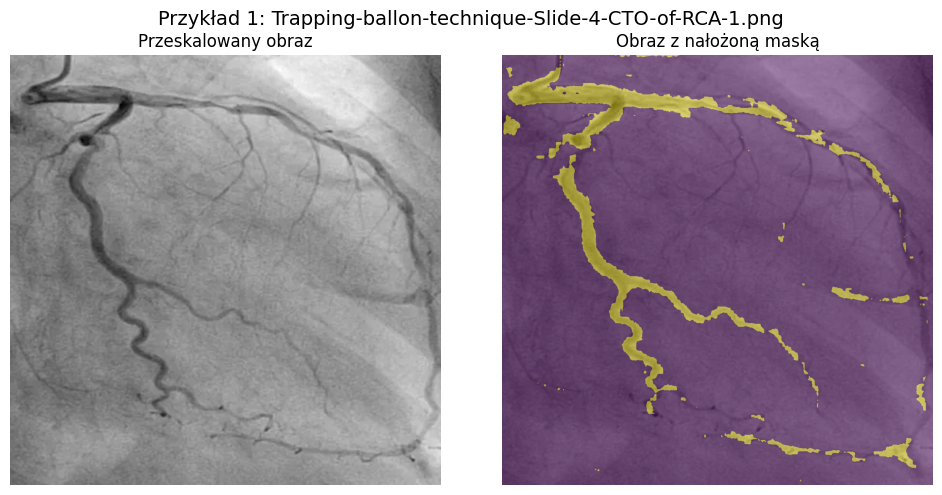

In [69]:
# Import niezbędnych bibliotek
import torch
import torch.nn.functional as F
import numpy as np
import os
import cv2  # Użyjemy OpenCV do zapisu obrazów
from google.colab import drive
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.build_sam import build_sam_vit_b # Import konkretnej funkcji budującej model


# --- Krok 1: Montowanie Dysku Google ---
# try:
#     drive.mount('/content/drive')
#     print("✅ Dysk Google został pomyślnie zamontowany.")
# except Exception as e:
#     print(f"❌ Błąd podczas montowania Dysku Google: {e}")


# --- Krok 2: Konfiguracja ścieżek ---
# !!! WAŻNE !!!
# Zmień poniższe ścieżki, aby wskazywały na odpowiednie foldery na Twoim Dysku Google.

# # Podstawowa ścieżka do Twojego folderu roboczego
# BASE_DRIVE_PATH = '/content/drive/MyDrive/'  # <-- ZMIEŃ NA WŁASNĄ

# # Ścieżka do folderu z obrazami, dla których chcesz wygenerować maski
# IMG_DIR = os.path.join(BASE_DRIVE_PATH, 'test')  # <-- ZMIEŃ W RAZIE POTRZEBY

# # Folder, w którym zostaną zapisane wygenerowane maski w formacie .png
# OUTPUT_DIR = os.path.join(BASE_DRIVE_PATH, 'test/predicted_masks')  # <-- ZMIEŃ W RAZIE POTRZEBY

# Ścieżka do checkpointu wytrenowanego modelu SAM
# MODEL_CHECKPOINT_PATH = 'sam_coronary.pth' # <-- ZMIEŃ W RAZIE POTRZEBY, jeśli nazwa pliku jest inna


print("-" * 50)
print("Konfiguracja ścieżek:")
print(f"📁 Obrazy wejściowe:  {IMG_DIR}")
print(f"💾 Folder wyjściowy:    {OUTPUT_DIR}")
print("-" * 50)


# --- Krok 3: Definicje funkcji (Inferencja i Wizualizacja) ---

def run_inference_and_save(model, dataloader, device, output_dir, num_samples=10):
    """
    Przeprowadza inferencję na modelu, generuje maski i zapisuje je do plików.
    """
    model.eval()
    # Upewnij się, że folder wyjściowy istnieje
    os.makedirs(output_dir, exist_ok=True)
    print(f"Wygenerowane maski zostaną zapisane w: {output_dir}")

    results_for_viz = []
    samples_processed = 0

    with torch.no_grad():
        for batch in dataloader:
            if samples_processed >= num_samples:
                break

            images = batch['image'].to(device)
            # Dataloader dla inferencji musi dostarczać `bbox` jako "podpowiedź" dla modelu
            bboxes = batch['bbox'].to(device)
            filenames = batch['filename']

            # Forward pass (przepuszczenie danych przez model)
            image_embeddings = model.image_encoder(images)
            if len(bboxes.shape) == 2:
                bboxes = bboxes.unsqueeze(1)

            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=None, boxes=bboxes, masks=None
            )
            low_res_logits, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            # Zwiększenie rozdzielczości masek do oryginalnego rozmiaru obrazu
            # UWAGA: TUTAJ MOŻE BYĆ PROBLEM Z ROZMIAREM JEŚLI OBRAZY WEJŚCIOWE NIE SĄ 1024x1024
            # SAM oczekuje, że wejściowe obrazy do inferencji będą w oryginalnym rozmiarze
            # przed set_image, a następnie predykcja jest skalowana do tego rozmiaru.
            # Tutaj Dataloader skaluje obraz do 1024x1024 przed predykcją.
            # Aby to naprawić, należałoby przekazać oryginalne rozmiary obrazów
            # z Dataloadera i użyć ich do interpolacji.
            # Na razie zakładamy, że interpolujemy do 1024x1024.
            original_size = (1024, 1024) # Zakładamy, że model był trenowany na 1024x1024
            predictions = F.interpolate(
                torch.sigmoid(low_res_logits),
                size=original_size, mode="bilinear", align_corners=False
            ).squeeze(1)

            # Zapisz predykcje i przygotuj dane do wizualizacji
            for j in range(len(images)):
                if samples_processed >= num_samples:
                    break

                # Konwertuj predykcję na maskę binarną (0 lub 1)
                pred_mask_tensor = (predictions[j].cpu() > 0.6).float()

                # Konwertuj maskę do formatu obrazu (wartości 0 lub 255)
                pred_mask_image = (pred_mask_tensor.numpy() * 255).astype(np.uint8)

                # Zapisz maskę jako plik .png
                input_filename = os.path.basename(filenames[j])
                output_filename = os.path.splitext(input_filename)[0] + '_mask.png'
                output_path = os.path.join(output_dir, output_filename)
                cv2.imwrite(output_path, pred_mask_image)

                # Zbierz dane potrzebne do późniejszej wizualizacji
                # W przypadku inferencji z Dataloadera, obraz w `batch['image']` jest już przeskalowany
                # do 1024x1024. Jeśli chcesz wizualizować na oryginalnym obrazie,
                # musiałbyś go załadować ponownie lub zmodyfikować Dataloader.
                results_for_viz.append({
                    'filename': filenames[j],
                    'image': images[j].cpu(), # Używamy przeskalowanego obrazu z batcha
                    'pred_mask': pred_mask_tensor.numpy()
                })
                samples_processed += 1

    print(f"\n✅ Zakończono inferencję. Zapisano {samples_processed} masek.")
    return results_for_viz
def run_inference_and_save_two(model, dataloader, device, output_dir, num_samples=10):
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    print(f"Wygenerowane maski zostaną zapisane w: {output_dir}")

    results_for_viz = []
    samples_processed = 0

    with torch.no_grad():
        for batch in dataloader:
            if samples_processed >= num_samples:
                break

            images = batch['image'].to(device)
            filenames = batch['filename']

            # Spróbuj pobrać bbox, jeśli nie ma — utwórz domyślne na podstawie rozmiaru obrazu
            if 'bbox' in batch:
                bboxes = batch['bbox'].to(device)
            else:
                B, C, H, W = images.shape
                bboxes = torch.tensor([[0, 0, W, H]] * B, dtype=torch.float32).to(device)

            if len(bboxes.shape) == 2:
                bboxes = bboxes.unsqueeze(1)

            image_embeddings = model.image_encoder(images)
            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=None, boxes=bboxes, masks=None
            )
            low_res_logits, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            original_size = (1024, 1024)
            predictions = F.interpolate(
                torch.sigmoid(low_res_logits),
                size=original_size, mode="bilinear", align_corners=False
            ).squeeze(1)

            for j in range(len(images)):
                if samples_processed >= num_samples:
                    break

                pred_mask_tensor = (predictions[j].cpu() > 0.6).float()
                pred_mask_image = (pred_mask_tensor.numpy() * 255).astype(np.uint8)

                input_filename = os.path.basename(filenames[j])
                output_filename = os.path.splitext(input_filename)[0] + '_mask.png'
                output_path = os.path.join(output_dir, output_filename)
                cv2.imwrite(output_path, pred_mask_image)

                results_for_viz.append({
                    'filename': filenames[j],
                    'image': images[j].cpu(),
                    'pred_mask': pred_mask_tensor.numpy()
                })
                samples_processed += 1

    print(f"\n✅ Zakończono inferencję. Zapisano {samples_processed} masek.")
    return results_for_viz


def visualize_inference_result(image, pred_mask, title):
    """Wizualizuje oryginalny obraz i nałożoną na niego predykcję maski."""
    # Konwersja obrazu z tensora do formatu, który można wyświetlić
    img_np = image.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min()) # Normalizacja do [0,1]

    plt.figure(figsize=(10, 5))

    # Wykres 1: Oryginalny obraz (przeskalowany przez Dataloader)
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title("Przeskalowany obraz")
    plt.axis('off')

    # Wykres 2: Obraz z nałożoną maską
    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    # Maska jest już w rozmiarze 1024x1024 po interpolacji
    plt.imshow(pred_mask.squeeze(), cmap='viridis', alpha=0.5) # Nakładanie maski z przezroczystością
    plt.title("Obraz z nałożoną maską")
    plt.axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# --- Krok 4: Ładowanie modelu SAM i uruchomienie inferencji ---
# Ten blok kodu zakłada, że masz już zdefiniowane i dostępne następujące zmienne:
# - `device`: Urządzenie, na którym przeprowadzane są obliczenia (np. 'cuda').
# - `dataloader`: Obiekt DataLoader zdefiniowany w poprzedniej komórce.

# Sprawdzenie warunków przed uruchomieniem
if ('device' in locals() and 'dataloader' in locals() and os.path.exists(IMG_DIR)):

    print("\n🤖 Ładowanie modelu SAM...")
    # Zbuduj pusty model o architekturze 'vit_b'
    # sam_model = build_sam_vit_b(checkpoint=None) # Nie ładuj checkpointu od razu
    # Załaduj wytrenowany checkpoint do modelu
    # try:
    #     # state_dict = torch.load(MODEL_CHECKPOINT_PATH, map_location=device)
    #     # sam_model.load_state_dict(state_dict)
    #     # sam_model.to(device)
    #     sam_model = torch.load('sam_coronary.pth', map_location=torch.device('cpu'))

    #     print(f"✅ Model SAM załadowany pomyślnie z {MODEL_CHECKPOINT_PATH} na {device}.")
    # except Exception as e:
    #     print(f"❌ Błąd podczas ładowania checkpointu modelu: {e}")
    #     sam_model = None # Ustaw model na None, aby zatrzymać dalszą inferencję


    if sam_model is not None:
        print("\n🚀 Rozpoczynanie inferencji...")

        NUM_INFERENCE_SAMPLES = 10  # Ile obrazów przetworzyć
        NUM_VISUAL_SAMPLES = 3      # Ile wyników pokazać w notatniku

        # Uruchom inferencję i zapisz maski
        viz_results = run_inference_and_save_two(
            model=sam_model,
            dataloader=dataloader_two,
            device=device,
            output_dir=OUTPUT_DIR,
            num_samples=NUM_INFERENCE_SAMPLES
        )

        # Wizualizacja kilku przykładowych wyników
        print("\n🖼️ Wizualizacja przykładowych wyników inferencji:")
        for i, result in enumerate(viz_results[:NUM_VISUAL_SAMPLES]):
            visualize_inference_result(
                image=result['image'],
                pred_mask=result['pred_mask'],
                title=f"Przykład {i+1}: {os.path.basename(result['filename'])}"
            )
else:
    print("\n⚠️ Zatrzymano. Nie można rozpocząć inferencji.")
    print("Upewnij się, że:")
    print(f"   1. Ścieżka IMG_DIR ('{IMG_DIR}') jest poprawna i wskazany folder istnieje.")
    print("   3. Zmienne 'device' i 'dataloader' zostały poprawnie zdefiniowane.")
    print("   4. Twój 'dataloader' dostarcza słownik z kluczami 'image', 'bbox' i 'filename'.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Podsumowanie i Następne Kroki

Gratulacje! Ukończyłeś kompletny pipeline treningu SAM/MedSAM na danych koronarograficznych.

### Co osiągnąłeś:
✅ Zainstalowałeś i skonfigurowałeś SAM/MedSAM  
✅ Przygotowałeś dataset dla danych koronarograficznych  
✅ Przeprowadziłeś fine-tuning modelu SAM  
✅ Oceniłeś wydajność przy użyciu metryk IoU, Dice i Accuracy  
✅ Zwizualizowałeś wyniki segmentacji  

### Następne kroki:
1. **Zbierz więcej danych**: Więcej danych treningowych = lepsza wydajność
2. **Eksperymentuj z hyperparametrami**: Learning rate, batch size, loss functions
3. **Różne prompt types**: Testuj punkty, boxy, kombinacje
4. **Data augmentation**: Rotacje, przeskalowania, zmiany kontrastu
5. **Ensemble methods**: Kombinuj predykcje z różnych modeli
6. **Post-processing**: Morfologiczne operacje, filtering
7. **Walidacja krzyżowa**: Podziel dane na train/val/test

### Przydatne zasoby:
- [SAM Official Repository](https://github.com/facebookresearch/segment-anything)
- [MedSAM Repository](https://github.com/bowang-lab/MedSAM)
- [Segment Anything Paper](https://arxiv.org/abs/2304.02643)
- [MedSAM Paper](https://arxiv.org/abs/2304.12306)

### Wskazówki optymalizacji:
- Użyj **mixed precision training** (`torch.cuda.amp`) dla szybszego treningu
- **Gradient accumulation** jeśli masz ograniczoną pamięć GPU
- **Learning rate scheduling** dla lepszej konwergencji
- **Early stopping** aby uniknąć overfittingu

**Powodzenia w segmentacji naczyń koronarograficznych! 🫀**